# Passive compliance — weight loading

How the hand's **torsional (joint-space) spring stiffness** determines the
steady-state finger deflection under incrementally added weights.  The four
fingers are commanded to hold `WEIGHT_POSE`; each weight step deflects them
further toward extension.  Higher stiffness → smaller angular deviation for
the same load.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('../../'))
from hand_config import (
    STIFFNESS_CONDITIONS,
    WEIGHT_FINGERS, WEIGHT_LABELS, WEIGHT_LOG_DURATION,
    WEIGHT_INDEX, WEIGHT_MIDDLE, WEIGHT_RING, WEIGHT_PINKY,
)
from plot_config import draw_radar

COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
OUTPUT = os.path.join('outputs', 'weight_compliance_hand')
os.makedirs(OUTPUT, exist_ok=True)

# Motor index of the MCP joint for each finger
FINGER_MCP_IDX = {'index': 5, 'middle': 7, 'ring': 9, 'pinky': 11}

# Per-finger MCP target [rad]
FINGER_TARGET = {
    'index':  WEIGHT_INDEX,
    'middle': WEIGHT_MIDDLE,
    'ring':   WEIGHT_RING,
    'pinky':  WEIGHT_PINKY,
}

# Step labels (for axis ticks: 0, 1, 2, 3)
N_STEPS = 1 + len(WEIGHT_LABELS)   # 0 = no weight, 1..3 = soft/medium/hard

# Line styles per finger (to distinguish within the same K color)
FINGER_LS = {'index': '-', 'middle': '--', 'ring': ':', 'pinky': '-.'}

def _synth(k):
    rng  = np.random.default_rng(int(k * 1000))
    rows = []
    t = 0.0; dt = 0.02
    n = int(WEIGHT_LOG_DURATION / dt)
    for step in range(N_STEPS):
        delta = (step / (N_STEPS - 1)) * (0.3 / k)
        for _ in range(n):
            q = np.zeros(13)
            for fname, midx in FINGER_MCP_IDX.items():
                tgt = FINGER_TARGET[fname]
                q[midx]   = max(0.0, tgt[0] - delta + rng.normal(0, 0.004))
                q[midx+1] = max(0.0, tgt[1] - delta * 0.6 + rng.normal(0, 0.004))
            row = {'time_s': f'{t:.3f}', 'k_rot': k, 'weight_step': step}
            row.update({f'q_{j}': f'{q[j]:.5f}' for j in range(13)})
            row.update({f'qdot_{j}': '0' for j in range(13)})
            row.update({f'tau_{j}': '0' for j in range(13)})
            rows.append(row); t += dt
    return pd.DataFrame(rows)

DEMO = False
def load(k):
    global DEMO
    path = os.path.join(OUTPUT, f'data_K{k:.3f}.csv')
    if os.path.isfile(path):
        return pd.read_csv(path)
    DEMO = True
    return _synth(k)

DATA = {k: load(k) for k in STIFFNESS_CONDITIONS}
banner = ' DEMO (synthetic) data ' if DEMO else ' measured data '
print(f'Loaded{banner}|  K levels: {STIFFNESS_CONDITIONS}')

Loaded measured data |  K levels: [0.05, 0.2, 0.6]


## Deviation from target vs weight step — per finger

Each line is one finger.  Color encodes stiffness condition; line style encodes finger.

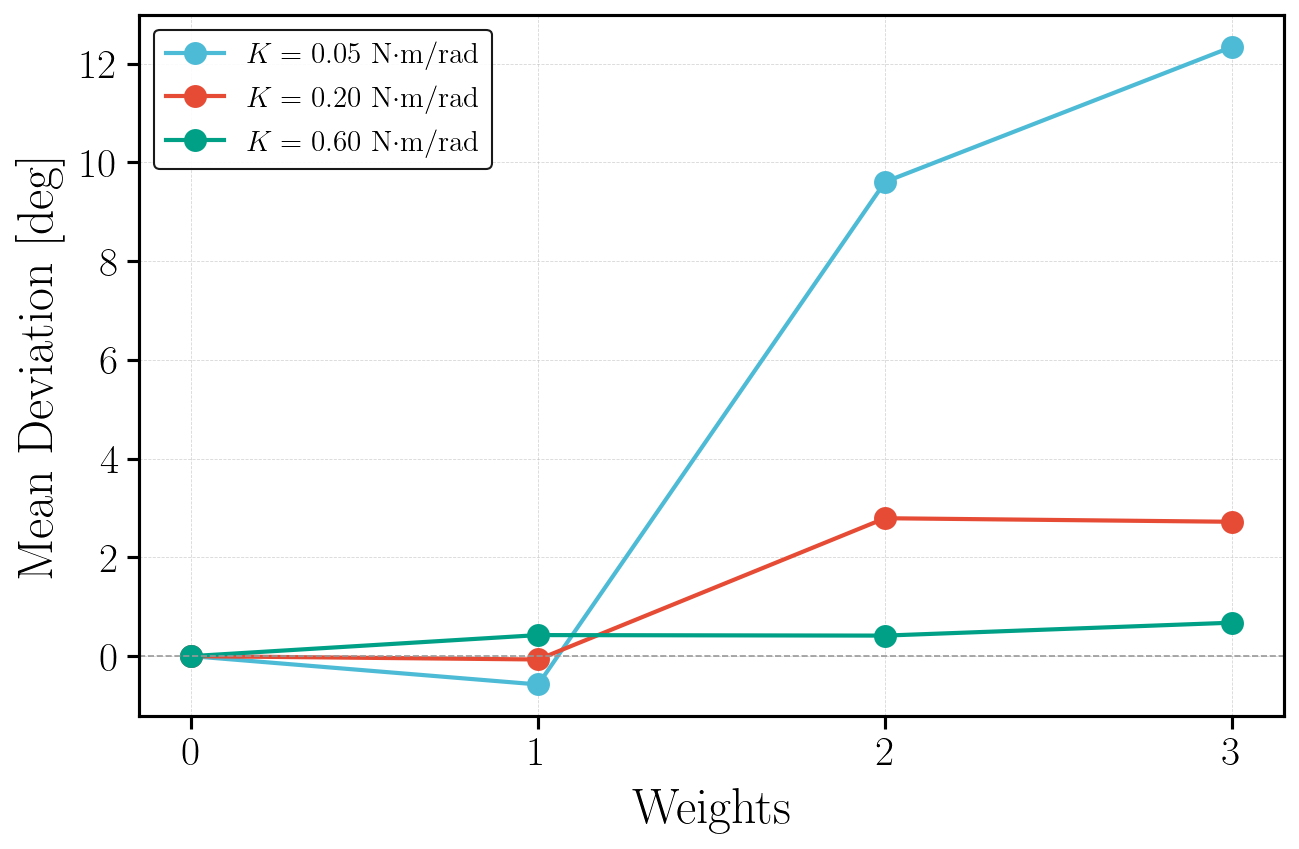

In [2]:
fig, ax = plt.subplots(figsize=(9, 6))

steps = list(range(N_STEPS))   # 0, 1, 2, 3

for i, k in enumerate(STIFFNESS_CONDITIONS):
    d   = DATA[k].copy()
    col = COLORS[i % len(COLORS)]

    means = []
    for s in steps:
        rows = d[d['weight_step'] == s]
        finger_devs = []
        for fname, midx in FINGER_MCP_IDX.items():
            baseline = np.rad2deg(d[d['weight_step'] == 0][f'q_{midx}'].astype(float).mean())
            q_mcp    = rows[f'q_{midx}'].astype(float)
            finger_devs.append(baseline - np.rad2deg(q_mcp).mean())
        means.append(np.mean(finger_devs))

    ax.plot(steps, means, 'o-', color=col, lw=2.0,
            label=rf'$K = {k:.2f}$ N$\cdot$m/rad')

ax.axhline(0, color='0.6', lw=0.8, ls='--')
ax.set_xticks(steps)
ax.set_xlabel('Weights')
ax.set_ylabel('Mean Deviation [deg]')
ax.legend(fontsize=14)
ax.grid(True, lw=0.4, alpha=0.5)
if DEMO:
    fig.text(0.5, 0.5, 'DEMO', fontsize=90, color='0.92',
             ha='center', va='center', rotation=30, zorder=0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'weight_deviation_vs_step.pdf'))
plt.show()

## Radar: per-finger deviation at each weight step

One panel per weight step (0 = no weight, 1–3 = soft/medium/hard).
Spokes = fingers.  Each trace is one stiffness condition.
Radii are normalised to the maximum deviation across all conditions and steps.

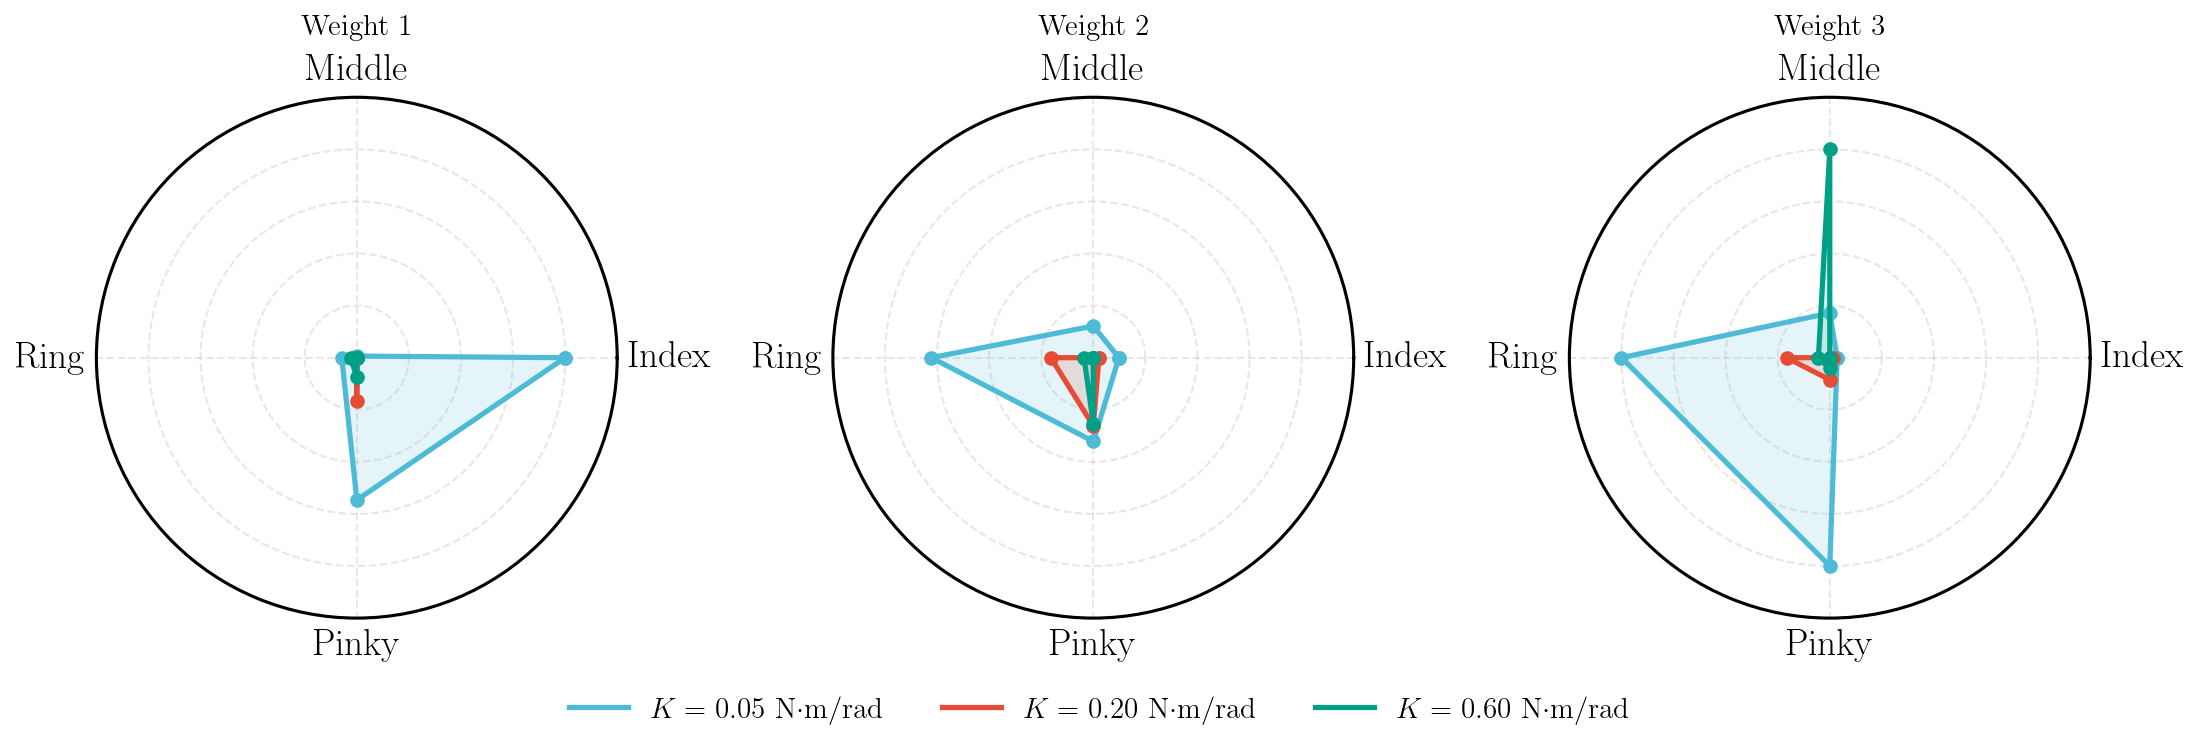

In [3]:
spokes      = [f.capitalize() for f in WEIGHT_FINGERS]
weight_steps = list(range(1, N_STEPS))          # 1, 2, 3 — baseline (step 0) is the reference
step_titles  = [f'Weight {i}' for i in weight_steps]

# Precompute per-finger baseline (step 0) for each K
baseline = {}
for k in STIFFNESS_CONDITIONS:
    d = DATA[k].copy()
    baseline[k] = {fname: np.rad2deg(d[d['weight_step'] == 0][f'q_{midx}'].astype(float).mean())
                   for fname, midx in FINGER_MCP_IDX.items()}

# Global vmax across all K and weight steps for consistent scale
all_devs = np.zeros((len(STIFFNESS_CONDITIONS), len(weight_steps), len(WEIGHT_FINGERS)))
for i, k in enumerate(STIFFNESS_CONDITIONS):
    d = DATA[k].copy()
    for si, s in enumerate(weight_steps):
        rows = d[d['weight_step'] == s]
        for j, (fname, midx) in enumerate(FINGER_MCP_IDX.items()):
            q_mcp = rows[f'q_{midx}'].astype(float)
            all_devs[i, si, j] = abs(baseline[k][fname] - np.rad2deg(q_mcp).mean())

vmax_global = np.max(all_devs, axis=(0, 1))
vmax_global = np.where(vmax_global < 1e-6, 1.0, vmax_global)

fig, axes = plt.subplots(1, len(weight_steps), figsize=(5 * len(weight_steps), 5),
                         subplot_kw=dict(projection='polar'))

for ax, s, title in zip(axes, weight_steps, step_titles):
    traces = []
    for i, k in enumerate(STIFFNESS_CONDITIONS):
        d    = DATA[k].copy()
        rows = d[d['weight_step'] == s]
        vals = [abs(baseline[k][fname] - np.rad2deg(rows[f'q_{midx}'].astype(float)).mean())
                for fname, midx in FINGER_MCP_IDX.items()]
        traces.append(dict(label=rf'$K={k:.2f}$', values=vals,
                           color=COLORS[i % len(COLORS)]))
    draw_radar(spokes, traces, ax=ax, vmax=vmax_global)
    ax.set_title(title, pad=30, fontsize=14)

handles = [plt.Line2D([0], [0], color=COLORS[i % len(COLORS)], lw=2.5,
                      label=rf'$K={k:.2f}$ N$\cdot$m/rad')
           for i, k in enumerate(STIFFNESS_CONDITIONS)]
fig.legend(handles=handles, loc='lower center', ncol=len(STIFFNESS_CONDITIONS),
           fontsize=14, frameon=False, bbox_to_anchor=(0.5, -0.05))

if DEMO:
    fig.text(0.5, 0.5, 'DEMO', fontsize=90, color='0.92',
             ha='center', va='center', rotation=30, zorder=0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'weight_deviation_radar.pdf'), bbox_inches='tight')
plt.show()

## Radar: per-finger deviation at each stiffness condition

One panel per stiffness condition.  Spokes = fingers.  Each trace is one weight step (1–3 = soft/medium/hard).  
Same global normalisation as the previous radar — radii comparable across both plots.

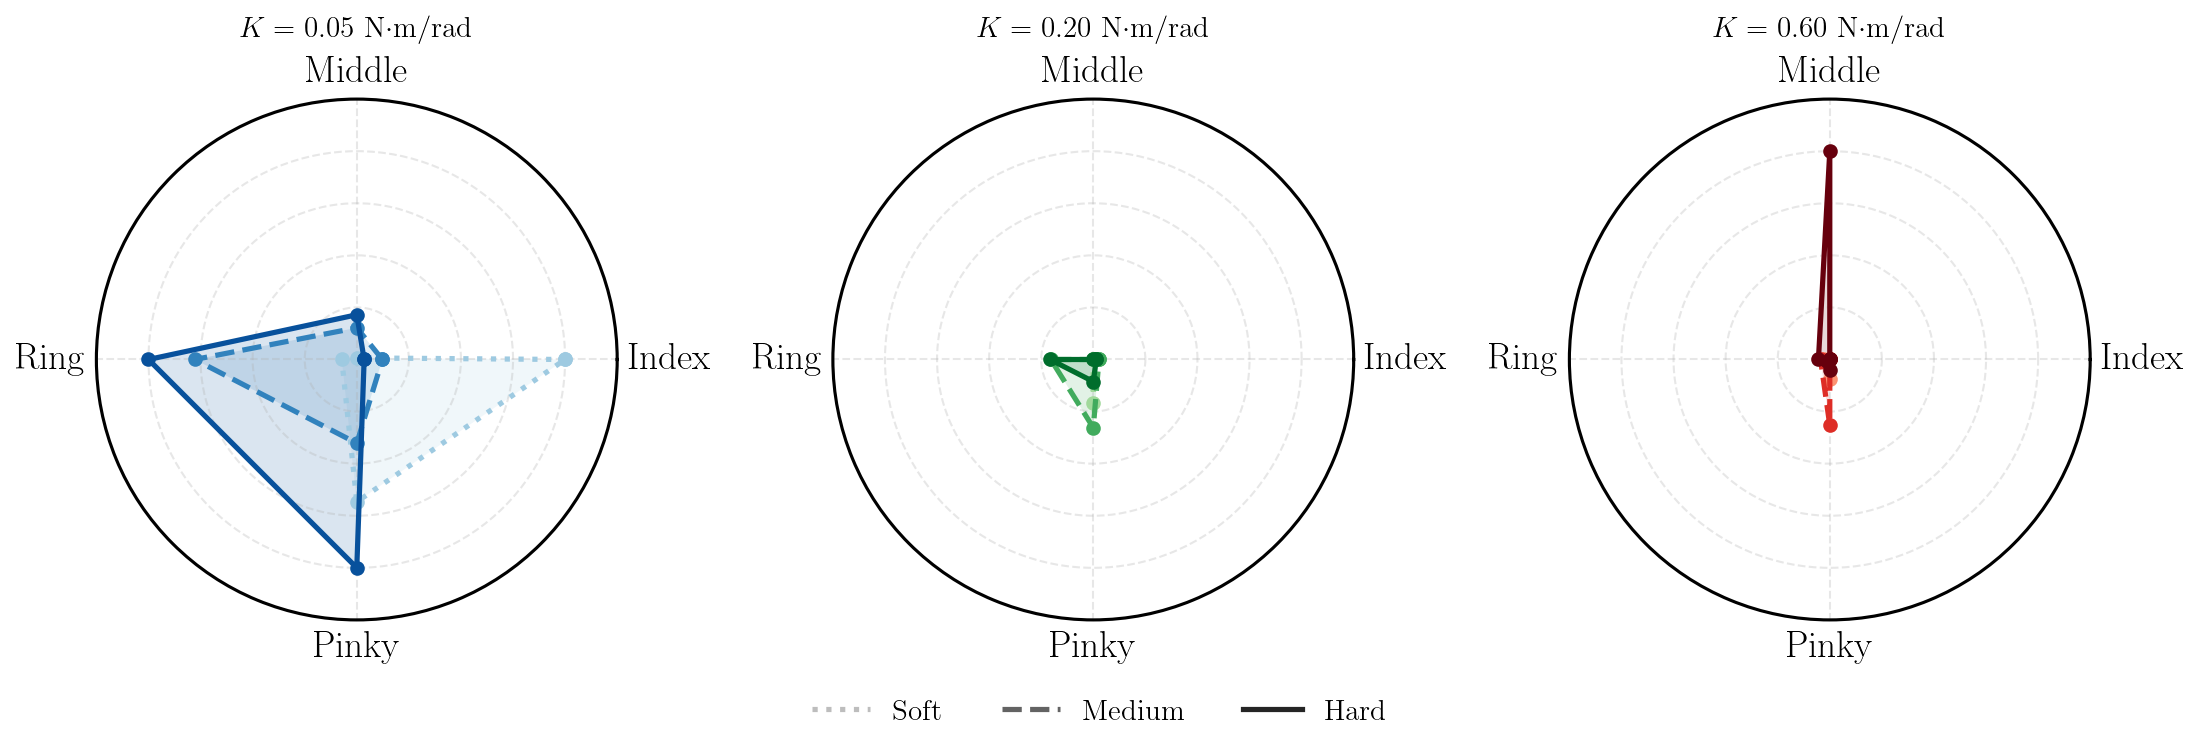

In [4]:
# Panels = stiffness conditions, traces = weight steps
spokes_k     = [f.capitalize() for f in WEIGHT_FINGERS]
weight_steps = list(range(1, N_STEPS))   # 1, 2, 3
step_labels  = WEIGHT_LABELS             # ['soft', 'medium', 'hard']
step_ls      = [':', '--', '-']          # soft=dotted, medium=dashed, hard=solid

# Per-panel shades: light → medium → dark for soft → medium → hard
PANEL_SHADES = [
    ['#9ecae1', '#3182bd', '#08519c'],   # blues  (K = 0.05)
    ['#a1d99b', '#41ab5d', '#006d2c'],   # greens (K = 0.20)
    ['#fc9272', '#de2d26', '#67000d'],   # reds   (K = 0.60)
]

# Reuse baseline and vmax_global computed in the cell above

fig, axes = plt.subplots(1, len(STIFFNESS_CONDITIONS),
                         figsize=(5 * len(STIFFNESS_CONDITIONS), 5),
                         subplot_kw=dict(projection='polar'))

for ax, k, shades in zip(axes, STIFFNESS_CONDITIONS, PANEL_SHADES):
    d = DATA[k].copy()
    traces = []
    for s, lbl, col, ls in zip(weight_steps, step_labels, shades, step_ls):
        rows = d[d['weight_step'] == s]
        vals = [abs(baseline[k][fname] - np.rad2deg(rows[f'q_{midx}'].astype(float)).mean())
                for fname, midx in FINGER_MCP_IDX.items()]
        traces.append(dict(label=lbl.capitalize(), values=vals, color=col, ls=ls))
    draw_radar(spokes_k, traces, ax=ax, vmax=vmax_global)
    ax.set_title(rf'$K = {k:.2f}$ N$\cdot$m/rad', pad=30, fontsize=14)

# Legend: grayscale swatches with matching line styles
legend_colors = ['#bdbdbd', '#636363', '#252525']
handles = [plt.Line2D([0], [0], color=col, lw=2.5, linestyle=ls, label=lbl.capitalize())
           for lbl, col, ls in zip(step_labels, legend_colors, step_ls)]
fig.legend(handles=handles, loc='lower center', ncol=len(weight_steps),
           fontsize=14, frameon=False, bbox_to_anchor=(0.5, -0.05))

if DEMO:
    fig.text(0.5, 0.5, 'DEMO', fontsize=90, color='0.92',
             ha='center', va='center', rotation=30, zorder=0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'weight_deviation_radar_per_k.pdf'), bbox_inches='tight')
plt.show()